In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import product
import random
from pprint import pprint

def gen_directed_graphs(n=4, m=15):
    graphs = defaultdict(list)

    for i in range(n):
        G = nx.DiGraph()  # Create a directed graph
        nodes = [j for j in range(m)]  # Create a list of nodes
        # edges = list(zip(nodes[:-1], nodes[1:]))  # Create edges between consecutive nodes

        # make sure the edge is not a loop
        # edges = [(random.choice(nodes), random.choice(nodes)) for _ in range(m)]
        used_nodes = set()
        edges = []

        while len(edges) < m:
            pos1 = random.choice(nodes)
            pos2 = random.choice(nodes)

            if (pos1, pos2) not in edges and (pos2, pos1) not in edges and pos1 != pos2:
                edges.append((pos1, pos2))
                used_nodes.add(pos1)
                used_nodes.add(pos2)

                # If we're about to finish but haven't used all nodes,
                # reject this attempt and start over
                remaining_edges = m - len(edges)
                unused_nodes = set(nodes) - used_nodes
                if remaining_edges < len(unused_nodes):
                    edges = []
                    used_nodes = set()

        # filter out edges from edges that loop
        # edges = [(u, v) for u, v in edges if u != v]
        
        # Assign random directions to edges
        random_edges = set()

        for u, v in edges:
            if random.choice([True, False]):  # Randomly decide the direction
                random_edges.add((u, v))
            else:
                random_edges.add((v, u))

        random_edges = list(random_edges)
        
        
        G.add_edges_from(random_edges)  # Add edges with random directions

        if(nx.number_weakly_connected_components(G) > 1):
            
            main_component = max(nx.weakly_connected_components(G), key=len)  # Find the largest connected component
            print(nx.number_weakly_connected_components(G))
            print(f"Main connected component: {main_component}")
            # iterate through weakly connected components aside the main one
            for component in [c for c in nx.weakly_connected_components(G) if c != main_component]:
                num_of_connections = random.randint(1, len(component))
                print(f"Weakly connected component: {component}")
                # choose random nodes from the component based on num_of_connections
                random_nodes = random.sample(sorted(component), num_of_connections)
                # connect each node from random_nodes to random node from the main component
                for node in random_nodes:
                    G.add_edge(node, random.choice(list(main_component)))

        else:
            print("one component")

        graphs[i] = G.to_undirected()
        
    return graphs

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:

                number_of_groups = random.randint(1,3)
                group_conditions = []

                for x in range(number_of_groups):

                    num_deps = random.randint(1, 3)
                    
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []

                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})

                    group_conditions.append(enabling_conditions)
                
                G.edges[edge]['enabling'] = group_conditions if len(group_conditions) > 0 else None
    
    return chains

def get_sample(vector, graphs):
    num_states = len(graphs[0].nodes())
    vec = list(vector)  # [1,2,3,4]
    for i in range(num_states):
        if vec[0] != i:
            yield vec, i

def filter_unique_paths(paths_lst):
    if not paths_lst:
        return []
    
    # Keep track of which paths should be excluded
    paths_to_exclude = set()
    
    # For each path, check if it contains any shorter path as a subsequence
    for path in paths_lst:
        for other_path in paths_lst:
            # Skip if same path or if other_path is not shorter
            if path == other_path or len(other_path) >= len(path):
                continue
                
            # Check if other_path is a subsequence of path
            j, k = 0, 0  # j for other_path, k for path
            while j < len(other_path) and k < len(path):
                if other_path[j] == path[k]:
                    j += 1
                k += 1
                
            # If other_path is a subsequence of path, exclude path
            if j == len(other_path):
                paths_to_exclude.add(tuple(path))
                break
    
    # Return all paths except those that contain shorter paths as subsequences
    return [path for path in paths_lst if tuple(path) not in paths_to_exclude]

def get_vectors(chains):
    states_per_chain = []
    for chain_id in range(len(chains)):
        states_per_chain.append(list(chains[chain_id].nodes()))
    
    return list(product(*states_per_chain))

def solve(curr_states, target_node, graphs, orig_state_len, log=[], depth=0):
    '''
    Solves the problem of reaching target node from current state in graphs by returning the resulting state and log of steps.
    Parameters:
        curr_states: list of current states of automatas; LIST of INTEGERS
        target_node: target node; INTEGER
        graphs: list of graphs; LIST of networkx graphs
        log: list of log messages; LIST of STRINGS
        depth: depth of recursion; INTEGER
    Returns:
        out: states of automatas after solving or None if no solution; LIST of INTEGERS/None
            out: log: list of log messages; LIST of STRINGS
    '''
    indent = '-'*depth*2
    # log.append(f"{'-'*50}")
    curr_states_cpy = curr_states.copy()
    log.append(f"{indent}S {curr_states_cpy} TN {target_node}")
    # get all paths from current state to target node
    paths_lst = list(nx.all_simple_paths(graphs[0], curr_states_cpy[0], target_node))
    # check if a shorter path isn't already in a different longer path
    paths_lst = filter_unique_paths(paths_lst)
    log.append(f"{indent}PL {paths_lst}")
    
    # check if there is a path
    if len(paths_lst) == 0:
        log.append(f"{indent}NOPATH {curr_states} TN {target_node}")
        return None, log
    
    # check if current node equals target node
    if curr_states_cpy[0] == target_node:
        log.append(f"{indent}REND {curr_states_cpy}")
        return curr_states_cpy, log
    
    # path or paths exist and we are not in target node
    for path in paths_lst:
        log.append(f"{indent}P {path}")
        # projdu hrany po ceste (3-4), ziskam enabling
        curr_states_cpy = curr_states.copy()
        rules = graphs[0].get_edge_data(curr_states_cpy[0], path[1])
        # pokud neexistuje enabling, projdu edge
        log.append(f"{indent}RLS {rules}")
        if rules == {}:
            log.append(f"{indent}NOR {curr_states_cpy} TN {target_node}")
            # pokud má path jeden node, tak je to konec
            # log.append(f"{indent}{orig_state_len - len(curr_states_cpy)} {'U' if path[1] > curr_states_cpy[0] else 'D'}")
            for i in range(len(path)-1):
                if(i+1 <= len(path)-1):
                    log.append(f"{indent}{path[i]} -> {path[i+1]}: {path[i+1]}")
            curr_states_cpy[0] = path[1]
            log.append(f"{indent}NORCH {curr_states_cpy}")

            return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)

        # pokud existuje enabling, tak treba automat 1 ma byt ve stavu 2 a automat 2 ma byt ve stavu 3
        # prvni vyresime prvni pravidlo a pak druhe
        else:
            for rule_set in rules['enabling']:
                log.append(f"{indent}RS {rule_set}")

                curr_states_cpy = curr_states.copy()
                found = True

                for rule in sorted(rule_set, key=lambda x: x['automata_id']): # sorted znamena setrizene od nejvice zavisleho po nejmene
                    log.append(f"{indent}RULE {rule}")
                    idx = max(rule['automata_id'] - (orig_state_len - len(curr_states_cpy)), 0)
                    current_sub_state, log = solve(curr_states_cpy[idx:], rule['node_id'], graphs[idx:], orig_state_len, log, depth+1)

                    log.append(f"{indent}RCH {current_sub_state}")
                    if current_sub_state == None:
                        found = False
                        break
                    log.append(f"{indent}SUB {curr_states_cpy}")
                    curr_states_cpy[idx:] = current_sub_state
                    log.append(f"{indent}SUBCH {curr_states_cpy}")

                if found:
                    log.append(f"{indent}SUBF {curr_states_cpy}")
                    # log.append(f"{indent}{orig_state_len - len(curr_states_cpy)} {'U' if path[1] > curr_states_cpy[0] else 'D'}")
                    for i in range(len(path)-1):
                        if(i+1 <= len(path)-1):
                            log.append(f"{indent}{path[i]} -> {path[i+1]}: {path[i+1]}")
                    curr_states_cpy[0] = path[1]
                    log.append(f"{indent}SUBSOLVED {curr_states_cpy}")
                    break
                else:
                    continue
            
            if found:
                return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)
            else:
                continue
    log.append(f"{indent}UNSOL {curr_states_cpy}")            
    return None, log

def process_graphs(graphs, states, target_nodes, orig_states_len, log=[]):
    log_cpy = log.copy()
    log_cpy.append("*"*30)
    states, log_cpy = solve(states, target_nodes[-1], graphs, orig_states_len, log=log_cpy)

    if len(graphs) == 1:
        return states, target_nodes, log_cpy

    if states is not None:
        log = log_cpy
        found = False
        rnd_target_nodes = [tn for tn in graphs[0].nodes() if tn != states[1]]
        random.shuffle(rnd_target_nodes)
        for i in rnd_target_nodes:
            target_nodes_cpy = target_nodes.copy()
            target_nodes_cpy.append(i)
            state_tmp, target_nodes_cpy, log_tmp = process_graphs(graphs[1:], states[1:], target_nodes_cpy, orig_states_len, log)
            if state_tmp is None:
                continue
            else:
                found = True
                log = log_tmp
                target_nodes = target_nodes_cpy
                states[1:] = state_tmp
                break

        if not found:
            states = None

    return states, target_nodes, log

In [11]:
graphs = add_enabling(gen_directed_graphs(n=4, m=8))

one component
one component
one component
one component


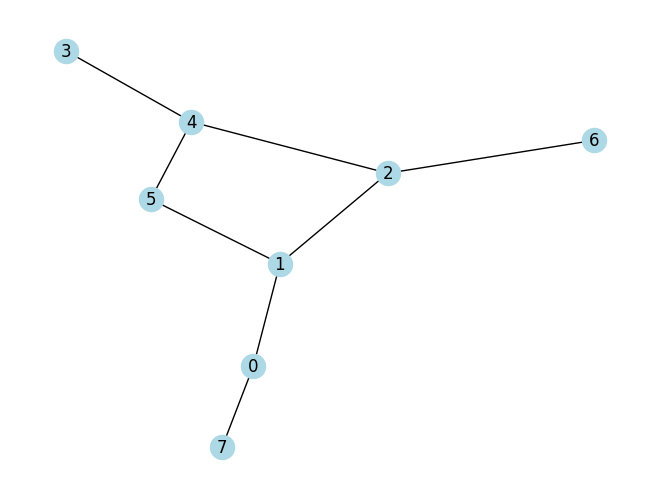

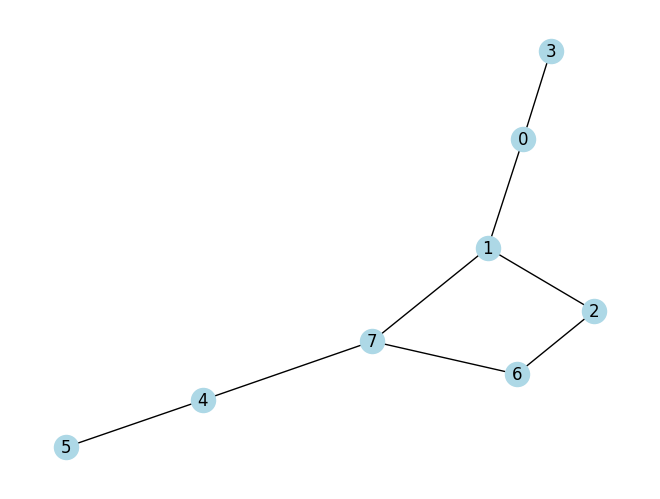

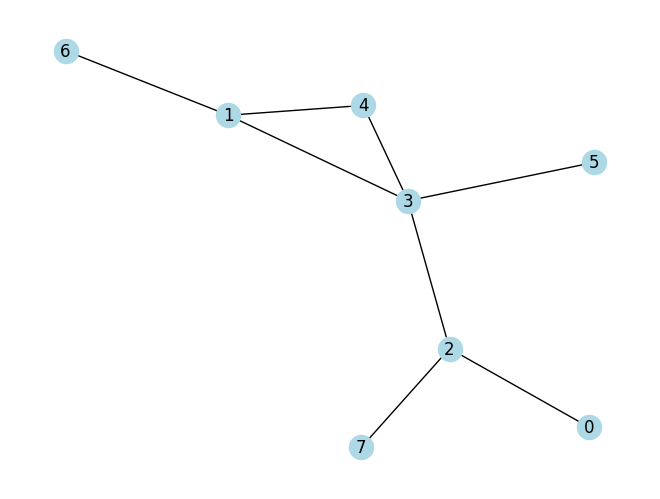

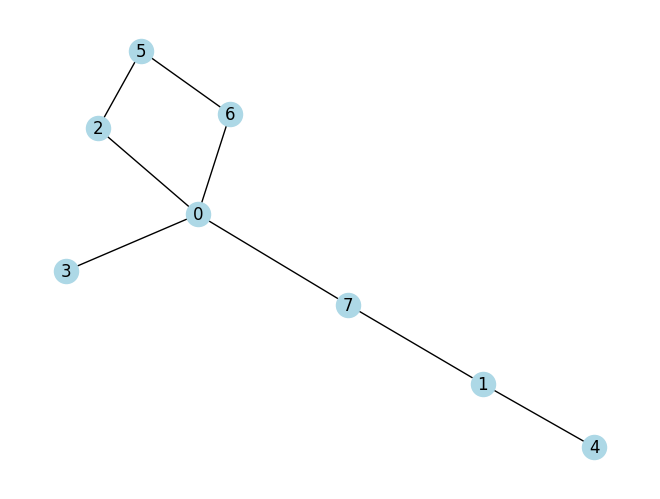

In [12]:
for i in range(len(graphs)):
    nx.draw(graphs[i], with_labels=True, node_color='lightblue', arrows=True)
    plt.show()

In [16]:
for chain_id in range(len(graphs)):
    print(f"\nChain {chain_id}:")
    G = graphs[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")



Chain 0:
Edge 0 -> 1: {'enabling': [[{'automata_id': 3, 'node_id': 6}], [{'automata_id': 2, 'node_id': 3}, {'automata_id': 3, 'node_id': 4}, {'automata_id': 1, 'node_id': 4}], [{'automata_id': 2, 'node_id': 5}]]}
Edge 0 -> 7: {}
Edge 1 -> 2: {}
Edge 1 -> 5: {'enabling': [[{'automata_id': 2, 'node_id': 2}, {'automata_id': 1, 'node_id': 1}], [{'automata_id': 2, 'node_id': 6}, {'automata_id': 3, 'node_id': 7}]]}
Edge 2 -> 6: {'enabling': [[{'automata_id': 1, 'node_id': 4}, {'automata_id': 2, 'node_id': 5}, {'automata_id': 3, 'node_id': 1}]]}
Edge 2 -> 4: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {'enabling': [[{'automata_id': 1, 'node_id': 5}]]}

Chain 1:
Edge 0 -> 1: {'enabling': [[{'automata_id': 3, 'node_id': 6}], [{'automata_id': 2, 'node_id': 0}, {'automata_id': 3, 'node_id': 7}], [{'automata_id': 3, 'node_id': 0}, {'automata_id': 2, 'node_id': 4}]]}
Edge 0 -> 3: {'enabling': [[{'automata_id': 2, 'node_id': 3}, {'automata_id': 3, 'node_id': 7}], [{'automata_id': 3, 'node_id': 4}, {'automata_i

In [17]:
vecs = get_vectors(graphs)
print(len(vecs))
print(vecs[0])

4096
(0, 0, 3, 7)


In [25]:
for i in get_sample(vecs[0], graphs):
    print(f"input vec: {i}")
    states, log_cpy = solve(i[0], i[1], list(graphs.values()), len(i[0]))
    pprint(log_cpy)
    break

input vec: ([0, 0, 3, 7], 1)
['S [0, 0, 3, 7] TN 1',
 'PL [[0, 1]]',
 'P [0, 1]',
 "RLS {'enabling': [[{'automata_id': 3, 'node_id': 6}], [{'automata_id': 2, "
 "'node_id': 3}, {'automata_id': 3, 'node_id': 4}, {'automata_id': 1, "
 "'node_id': 4}], [{'automata_id': 2, 'node_id': 5}]]}",
 "RS [{'automata_id': 3, 'node_id': 6}]",
 "RULE {'automata_id': 3, 'node_id': 6}",
 '--S [7] TN 6',
 '--PL [[7, 0, 6]]',
 '--P [7, 0, 6]',
 '--RLS {}',
 '--NOR [7] TN 6',
 '--7 -> 0: 0',
 '--0 -> 6: 6',
 '--NORCH [0]',
 '----S [0] TN 6',
 '----PL [[0, 6]]',
 '----P [0, 6]',
 '----RLS {}',
 '----NOR [0] TN 6',
 '----0 -> 6: 6',
 '----NORCH [6]',
 '------S [6] TN 6',
 '------PL [[6]]',
 '------REND [6]',
 'RCH [6]',
 'SUB [0, 0, 3, 7]',
 'SUBCH [0, 0, 3, 6]',
 'SUBF [0, 0, 3, 6]',
 '0 -> 1: 1',
 'SUBSOLVED [1, 0, 3, 6]',
 '--S [1, 0, 3, 6] TN 1',
 '--PL [[1]]',
 '--REND [1, 0, 3, 6]',
 'S [0, 0, 3, 7] TN 1',
 'PL [[0, 1]]',
 'P [0, 1]',
 "RLS {'enabling': [[{'automata_id': 3, 'node_id': 6}], [{'automata

In [ ]:
# více target nodů nebo jeden?
# logování